In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Read CSV
df = pd.read_csv('iris.csv')
#print(df.head(1))
# Exclude first and last columns
X = df.iloc[:, 1:-1].values
# Scale X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# apply KMeans to the dataset
kmeans = KMeans(n_clusters=3)
kmeans.fit(X_scaled)
row_cluster_map=kmeans.predict(X_scaled)
print(row_cluster_map)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 2 2 2 0 2 0 2 0 2 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 2 2 2 2 2 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 0 2
 2 2]


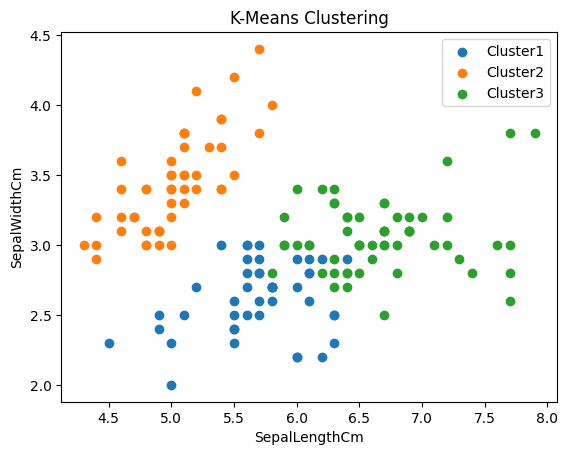

In [9]:
# plot cluster data
for i in np.unique(row_cluster_map):
    plt.scatter(x=X[row_cluster_map ==i, 0],
                y=X[row_cluster_map ==i, 1],
                label='Cluster'+str(i+1))
    
plt.title("K-Means Clustering")
plt.xlabel(df.columns[1])
plt.ylabel(df.columns[2])
plt.legend()
plt.show()

In [10]:
# WCSS
wcss = kmeans.inertia_
print("WCSS:", wcss)

WCSS: 142.1106371310419


In [11]:
# Silhouette
sil_score = silhouette_score(
    X_scaled,
    kmeans.labels_
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.45542721937148334
